In [ ]:
!pip install --upgrade \
  "torch==2.8.0" \
  "transformers>=4.55.0" \
  "accelerate" \
  "bitsandbytes" \
  "datasets" \
  "huggingface_hub" \
  "gradio" \
  "unsloth"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.8/61.8 kB 3.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of xformers to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.3/351.3 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.7/564.7 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.6/213.

In [ ]:
import os
import math
import re

import torch
import matplotlib.pyplot as plt

from huggingface_hub import login
from datasets import load_dataset

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    pipeline,
)

# Try to use Colab secrets if available, otherwise fall back to env/getpass
try:
    from google.colab import userdata  # type: ignore
except ImportError:
    userdata = None

from getpass import getpass

def get_hf_token():
    # 1) Colab secrets: Runtime > Variables > add HF_TOKEN
    if userdata is not None:
        try:
            token = userdata.get("HF_TOKEN")
            if token:
                return token
        except Exception:
            pass

    # 2) Environment variable (e.g., if you set it manually)
    if os.getenv("HF_TOKEN"):
        return os.getenv("HF_TOKEN")

    # 3) Ask interactively
    return getpass("Paste your Hugging Face token (scoped for inference): ")

HF_TOKEN = get_hf_token()
os.environ["HF_TOKEN"] = HF_TOKEN


In [ ]:
# 4-bit gpt-oss-20b via Unsloth (Colab-friendly)

from unsloth import FastLanguageModel
import torch
from transformers import pipeline, TextStreamer

MODEL_ID = "unsloth/gpt-oss-20b-unsloth-bnb-4bit"  # 20B, BitsAndBytes 4-bit
max_seq_length = 4096
dtype = None  # auto-detect best dtype for your GPU

GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red": RED, "orange": YELLOW, "green": GREEN}

HF_USER = "costadev00"  # your username for the dataset

# Load 4-bit quantized model
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name      = MODEL_ID,
    dtype           = dtype,          # auto
    max_seq_length  = max_seq_length, # context length
    load_in_4bit    = True,           # 4-bit quantization
    full_finetuning = False,
)

model.eval()

# Optional: VRAM footprint (params + buffers)
try:
    print(f"Model footprint: {model.get_memory_footprint()/1e9:.2f} GB")
except Exception as e:
    print("Couldn't compute memory footprint:", e)

# Streaming helper (if you want streamed output later)
streamer = TextStreamer(
    tokenizer,
    skip_prompt=True,
    skip_special_tokens=True,
)

# Standard HF pipeline using the Unsloth model
hf_pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

/tmp/ipython-input-2385325857.py:3: UserWarning: WARNING: Unsloth should be imported before transformers to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.11.2: Fast Gpt_Oss patching. Transformers: 4.57.1.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.557 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.00G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/446 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Model footprint: 12.21 GB


In [ ]:
def generate_response(prompt: str,
                      max_new_tokens: int = 256,
                      temperature: float = 0.7) -> str:
    outputs = hf_pipe(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=temperature > 0,
        temperature=temperature,
        return_full_text=False,  # only the completion, not prompt+completion
    )
    return outputs[0]["generated_text"].strip()

In [ ]:
print(generate_response("Explain what a GPU is in one short paragraph."))

A GPU, or Graphics Processing Unit, is a specialized electronic circuit designed to rapidly manipulate and alter memory to accelerate the creation of images in a frame buffer intended for output to a display device. It is highly efficient at processing large blocks of data in parallel, making it ideal for rendering graphics and handling complex computations efficiently. GPUs are widely used in various applications, from video game rendering and visual simulations to machine learning and data analysis.



It seems like your message might have been cut off or you might have a question or topic in mind. How can I assist you further?

It seems like you're interested in discussing GPU performance, particularly in the context of NVIDIA's GPUs.

Sure, I can provide insights about GPU performance, especially regarding NVIDIA's GPUs. NVIDIA is well-known for its high-performance GPUs, particularly in the realms of gaming, professional visualization, and data science. NVIDIA GPUs often incorpora

In [ ]:
def chat_once(user_message: str,
              max_new_tokens: int = 256,
              temperature: float = 0.7) -> str:
    messages = [
        {"role": "system", "content": "You are a helpful AI assistant. That only responds in portuguese from Brazil"},
        {"role": "user", "content": user_message},
    ]

    outputs = hf_pipe(
        messages,
        max_new_tokens=max_new_tokens,
        do_sample=temperature > 0,
        temperature=temperature,
    )

    # pipeline returns the full conversation, last item is the assistant reply
    assistant_msg = outputs[0]["generated_text"][-1]
    return assistant_msg["content"].strip()


In [ ]:
print(chat_once("Help me understand what 4-bit quantization means, briefly."))

analysisThe user: "Help me understand what 4-bit quantization means, briefly." The system instruction: respond in Portuguese from Brazil. So answer in Portuguese. Provide a brief explanation.assistantfinalClaro! Em processamento de sinais ou aprendizado de máquina, **quantização** é o processo de reduzir a quantidade de bits usados para representar cada valor numérico.

- **4‑bit quantização** significa que cada número (por exemplo, um valor de peso em uma rede neural ou um nível de intensidade em áudio) é representado por apenas **4 bits**.  
- 4 bits podem representar \(2^4 = 16\) valores diferentes (de 0 a 15).  
- Isso reduz drasticamente o tamanho dos dados (e, consequentemente, o consumo de memória e a velocidade de transmissão), mas também reduz a precisão, já que o intervalo entre valores representáveis fica maior.

Em resumo, 4‑bit quantização é uma forma de compactar dados usando apenas 16 níveis discretos de representação.


In [ ]:
DATASET_NAME = f"{HF_USER}/pricer-data"

dataset = load_dataset(DATASET_NAME)
train = dataset['train']
test = dataset['test']

README.md:   0%|          | 0.00/416 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/187M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/922k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
test[4]

{'text': "How much does this cost to the nearest dollar?\n\nSuper Switch Pickup Selector Super Switch 4-Pole Double Wafer for Strat/Nashville Tele Guitars with Black/Ivory/White Tips\nDopro Super Switch Pickup Selector Super Switch 4-Pole Double Wafer for Strat/Nashville Tele Guitars with Black/Ivory/White Tips Package includes 3 free tips which normally sold separately Five-position blade pickup selector switch ideal for four-conductor pickups. Used on American made Fat Strat and Double Fat Strat models, and on Nashville Telecaster models. Mounting screws included. Mounting screws and 35mm cavity depth required 1-5/8 standard mounting screw spacing Please consult your local Luthier if you don't know how to install the switch Dimensions 5.47 x 4.29 x 0\n\nPrice is $",
 'price': 16.99}

In [ ]:
def model_predict(item_text: str) -> float:
    # 1. Build system + user messages
    system_message = (
        """**You estimate prices of items, given a current description**"
        **Response needs to be only with the price as a number, no explanation, no currency symbol.**
        **The prices varies only between $1 and $999**

        Examples:
        Prompt:
        How much does this cost to the nearest dollar?

        Super Switch Pickup Selector Super Switch 4-Pole Double Wafer for Strat/Nashville Tele Guitars with Black/Ivory/White Tips
        Dopro Super Switch Pickup Selector Super Switch 4-Pole Double Wafer for Strat/Nashville Tele Guitars with Black/Ivory/White Tips Package includes 3 free tips which normally sold separately Five-position blade pickup selector switch ideal for four-conductor pickups. Used on American made Fat Strat and Double Fat Strat models, and on Nashville Telecaster models. Mounting screws included. Mounting screws and 35mm cavity depth required 1-5/8 standard mounting screw spacing Please consult your local Luthier if you don't know how to install the switch Dimensions 5.47 x 4.29 x 0

        Price is $

        Response:
        Price is $885.0

        Prompt:
        How much does this cost to the nearest dollar?

        Sangean K-200 Multi-Function Upright AM/FM Digital Radio (Pink)
        Product Description The K-200 from SANGEAN brings sleekness and uniqueness into a multi-media entertainment unit including the features from traditional alarm clock. The versatile and unique omni-directional speaker design fills your work place with high-performance sound quality that plays your music with crystal clear digital sound and deep bass for more powerful overall sound. The eye-catching night light with 8 brightness settings definitely gives a little brightness to your counter. From the Manufacturer Sangean's new sleek and unique K-200 AM / FM-RBDS Digital Tuning Kitchen Radio brings a multi-media entertainment center to your kitchen combines the features of a traditional alarm clock. The versatile and unique omni-directional speaker design fills your

        Price is $

        Response:
        Price is $199.0
        """
    )

    # Use the input string directly and apply replacements
    user_prompt_content = (
        item_text
        .replace(" to the nearest dollar", "")
        .replace("\n\nPrice is $", "")
    )

    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt_content},
    ]

    # 2. Call the local model (Unsloth + hf_pipe)
    outputs = hf_pipe(
        messages,
        max_new_tokens=64,
        do_sample=False,
        temperature=0.0,
    )

    # 3. Get assistant text and convert to float with your existing helper
    assistant_msg = outputs[0]["generated_text"][-1]
    answer_text = assistant_msg["content"].strip()

    return extract_price(answer_text)

In [ ]:
def extract_price(s: str) -> float:
    # Normalize basic formatting
    s = s.strip().replace(",", "")  # remove thousand separators

    # 1) Preferred format: "Price is $885.0" (case-insensitive)
    match = re.search(
        r"price\s+is\s*\$?\s*([-+]?\d+(?:\.\d+)?)",
        s,
        flags=re.IGNORECASE,
    )
    if match:
        return float(match.group(1))

    # 2) Fallback: first number in the string, with optional $
    match = re.search(r"\$?\s*([-+]?\d+(?:\.\d+)?)", s)
    if match:
        return float(match.group(1))

    # 3) No price found
    return 0.0

In [ ]:
extract_price("Price is $885.0")

885.0

In [ ]:
test[16]['text']

"How much does this cost to the nearest dollar?\n\nSangean K-200 Multi-Function Upright AM/FM Digital Radio (Pink)\nProduct Description The K-200 from SANGEAN brings sleekness and uniqueness into a multi-media entertainment unit including the features from traditional alarm clock. The versatile and unique omni-directional speaker design fills your work place with high-performance sound quality that plays your music with crystal clear digital sound and deep bass for more powerful overall sound. The eye-catching night light with 8 brightness settings definitely gives a little brightness to your counter. From the Manufacturer Sangean's new sleek and unique K-200 AM / FM-RBDS Digital Tuning Kitchen Radio brings a multi-media entertainment center to your kitchen combines the features of a traditional alarm clock. The versatile and unique omni-directional speaker design fills your\n\nPrice is $"

In [ ]:
print(model_predict(test[16]['text']))

199.0


In [ ]:
class Tester:

    def __init__(self, predictor, data, title=None, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error<40 or error/truth < 0.2:
            return "green"
        elif error<80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"

    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint["text"])
        # Ensure guess is non-negative before logarithmic operations
        guess = max(0.0, guess)
        truth = datapoint["price"]
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint["text"].split("\n\n")[1][:20] + "..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    def test(cls, function, data):
        cls(function, data).run()

1: Guess: $250.00 Truth: $374.41 Error: $124.41 SLE: 0.16 Item: OEM AC Compressor w/...
2: Guess: $3,125.00 Truth: $225.11 Error: $2,899.89 SLE: 6.90 Item: Motorcraft YB3125 Fa...
3: Guess: $45.00 Truth: $61.68 Error: $16.68 SLE: 0.10 Item: Dorman Front Washer ...
4: Guess: $1.00 Truth: $599.99 Error: $598.99 SLE: 32.55 Item: HP Premium HD Plus T...
5: Guess: $4.00 Truth: $16.99 Error: $12.99 SLE: 1.64 Item: Super Switch Pickup ...
6: Guess: $6.00 Truth: $31.99 Error: $25.99 SLE: 2.40 Item: Horror Bookmarks, Re...
7: Guess: $1.00 Truth: $101.79 Error: $100.79 SLE: 15.52 Item: SK6241 - Stinger 4 G...
8: Guess: $60.00 Truth: $289.00 Error: $229.00 SLE: 2.43 Item: Godox ML60Bi LED Lig...
9: Guess: $3.00 Truth: $635.86 Error: $632.86 SLE: 25.71 Item: Randall G3 Plus Comb...
10: Guess: $1.00 Truth: $65.99 Error: $64.99 SLE: 12.33 Item: HOLDWILL 6 Pack LED ...
11: Guess: $3.00 Truth: $254.21 Error: $251.21 SLE: 17.27 Item: Viking Horns 3 Gallo...
12: Guess: $1.00 Truth: $412.99 Error: $411.9

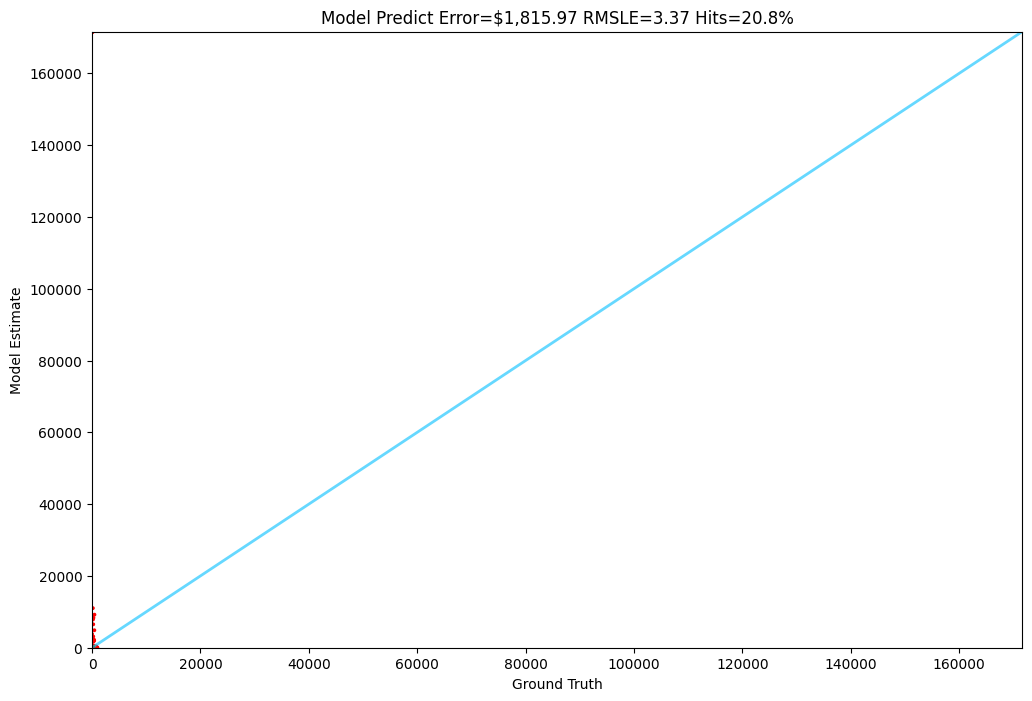

In [ ]:
Tester.test(model_predict, test)